In [39]:
# LOCATION : https://github.com/purnasai/Dino_V2
import torch
import os

os.environ["XFORMERS_DISABLED"] = "1" # Switch to enable xFormers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")


/media/osero/SamsungSSD/miniconda_files/conda/envs/dinov2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/osero/SamsungSSD/miniconda_files/conda/envs/dinov2/lib/python3.10/site-packages/torch/cuda/__init__.py:88: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525541990/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [40]:
# large model
dinov2_vitl14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(device)

Using cache found in /home/osero/.cache/torch/hub/facebookresearch_dinov2_main
/home/osero/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:45: UserWarning: xFormers is disabled (SwiGLU)
  warnings.warn("xFormers is disabled (SwiGLU)")
/home/osero/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/osero/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:29: UserWarning: xFormers is disabled (Attention)
  warnings.warn("xFormers is disabled (Attention)")
/home/osero/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/osero/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:35: UserWarning: xFormers is disabled (Block)
  warnings.warn("xFormers is disable

KeyboardInterrupt: 

In [ ]:
import requests
from PIL import Image
from torchvision import transforms
# transform = transforms.Compose([           
#                                 transforms.Resize(256),                    
#                                 transforms.CenterCrop(224),               
#                                 transforms.ToTensor(),                    
#                                 transforms.Normalize(                      
#                                 mean=[0.485, 0.456, 0.406],                
#                                 std=[0.229, 0.224, 0.225]              
#                                 )])

transform = transforms.Compose([           
                                transforms.Resize(512),                    
                                transforms.CenterCrop(448),               
                                transforms.ToTensor(),                    
                                transforms.Normalize(                      
                                mean=[0.485, 0.456, 0.406],                
                                std=[0.229, 0.224, 0.225]              
                                )])

# transform1 = transforms.Compose([           
#                                 transforms.Resize(520),
#                                 transforms.CenterCrop(518), #should be multiple of model patch_size                 
#                                 transforms.ToTensor(),                    
#                                 transforms.Normalize(mean=0.5, std=0.2)
#                                 ])

In [ ]:
import math


patch_size = dinov2_vitl14.patch_size # patchsize=14

#520//14
# patch_h  = 520//patch_size
# patch_w  = 520//patch_size

# feat_dim = 384 # vits14
# feat_dim = 768 # vitb14
feat_dim = 1024 # vitl14
# feat_dim = 1536 # vitg14

img_path = "/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256/0001/User_2_001/029.jpg"

total_features  = []
with torch.no_grad():
  img = Image.open(img_path).convert('RGB')
  img_t = transform(img)
  
  features_dict = dinov2_vitl14.forward_features(img_t.unsqueeze(0).to(device))
  features = features_dict['x_norm_patchtokens']
  total_features.append(features)

total_features = torch.cat(total_features, dim=0)
number_of_images = total_features.shape[0]
patch_size = int(math.sqrt(total_features.shape[1]))
total_features.shape


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# First PCA to Seperate Background
# sklearn expects 2d array for traning
total_features = total_features.reshape(number_of_images * patch_size * patch_size, feat_dim).cpu()#4(*H*w, 1024)

pca = PCA(n_components=3)
pca.fit(total_features)
pca_features = pca.transform(total_features)

# # visualize PCA components for finding a proper threshold
# # 3 histograms for 3 components
# plt.subplot(2, 2, 1)
# plt.hist(pca_features[:, 0])
# plt.subplot(2, 2, 2)
# plt.hist(pca_features[:, 1])
# plt.subplot(2, 2, 3)
# plt.hist(pca_features[:, 2])
# plt.show()
# plt.close()

In [ ]:
# min_max scale
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
#pca_features = sklearn.processing.minmax_scale(pca_features)

# plt.imshow(pca_features[0 : patch_h*patch_w, 0].reshape(patch_h, patch_w))

# plt.show()

In [ ]:
# segment/seperate the backgound and foreground using the first component
pca_features_bg = pca_features[:, 0] > 0.5# from first histogram
pca_features_fg = ~pca_features_bg

# plot the pca_features_bg
plt.imshow(pca_features_bg[0: patch_size * patch_size].reshape(patch_size, patch_size))

plt.show()


# 2nd PCA for only foreground patches
pca.fit(total_features[pca_features_fg]) 
pca_features_left = pca.transform(total_features[pca_features_fg])

for i in range(3):
    # min_max scaling
    pca_features_left[:, i] = (pca_features_left[:, i] - pca_features_left[:, i].min()) / (pca_features_left[:, i].max() - pca_features_left[:, i].min())

pca_features_rgb = pca_features.copy()
# for black background
pca_features_rgb[pca_features_bg] = 0
# new scaled foreground features
pca_features_rgb[pca_features_fg] = pca_features_left

# reshaping to numpy image format
pca_features_rgb = pca_features_rgb.reshape(number_of_images, patch_size, patch_size, 3)
plt.imshow(pca_features_rgb[0])

plt.show()

In [ ]:
import shutil
from PIL import Image
import numpy as np

converted_path = os.path.relpath(img_path, "/media/osero/SamsungSSD/CMPE_SSD")
converted_path = converted_path.replace("/", "_")
base, ext = os.path.splitext(converted_path)
modified_path = f"{base}_PCA{ext}"

im = Image.fromarray((pca_features_rgb[0] * 255).astype(np.uint8))
resized_image = im.resize((256,256), Image.NEAREST)
resized_image.save(modified_path)

shutil.copy2(img_path, converted_path)

# Joints

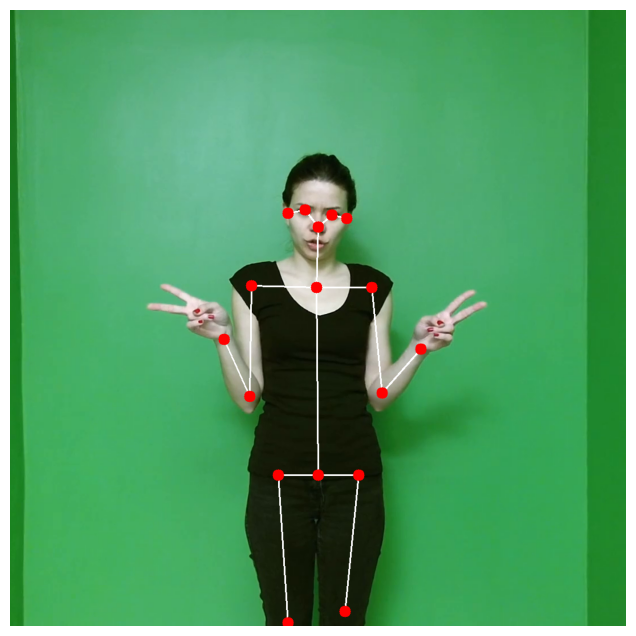

In [77]:
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# OpenPose BODY_25 Keypoint Pairs
POSE_PAIRS = [
    (1, 2), (2, 3), (3, 4),  # Right Arm
    (1, 5), (5, 6), (6, 7),  # Left Arm
    (1, 8), (8, 9), (9, 10), (10, 11),  # Right Leg
    (8, 12), (12, 13), (13, 14),  # Left Leg
    (1, 0), (0, 15), (15, 17), (0, 16), (16, 18),  # Head
    (11, 22), (22, 23), (23, 24),  # Right Foot
    (14, 19), (19, 20), (20, 21)   # Left Foot
]
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define OpenPose BODY_25 keypoints using your names

# Define POSE_PAIRS using your keypoint names
POSE_PAIRS = [
    ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),  # Right Arm
    ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),  # Left Arm
    ("neck", "middle_hip"), ("middle_hip", "right_hip"), ("right_hip", "right_knee"),  # Right Leg (With Knee)
    ("middle_hip", "left_hip"), ("left_hip", "left_knee"),  # Left Leg (With Knee)
    ("neck", "nose"), ("nose", "right_eye"), ("right_eye", "right_ear"), ("nose", "left_eye"), ("left_eye", "left_ear")  # Head
]

# # Load the image
# sample = "0001/User_2_001"
# frame_number = 28  # Change this to the frame you need

sample = "0002/User_3_003"
frame_number = 35  # Change this to the frame you need

video_path = f"/media/osero/SamsungSSD/CMPE_SSD/videos/{sample}.mp4"  # Change to your actual video file path

# Open the video file
cap = cv2.VideoCapture(video_path)

# Set the frame number you want to extract

# Set the video to the desired frame
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

# Read the frame
ret, image = cap.read()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

file_path = f"/media/osero/SamsungSSD/CMPE_SSD/skeleton_openpose/{sample}.pickle"

file = open(file_path, 'rb')
data = pickle.load(file)
keypoints = data['pose']

# Draw limbs
for pair in POSE_PAIRS:
    partA, partB = pair
    if partA in keypoints and partB in keypoints:
        xA, yA, cA = keypoints[partA][frame_number]
        xB, yB, cB = keypoints[partB][frame_number]
        cv2.line(image, (int(xA), int(yA)), (int(xB), int(yB)), (255, 255, 255), 2)  # Green lines for limbs
        
# Draw keypoints
for coord in keypoints.items():
    x, y, c = coord[1][frame_number]
    # x, y = coord
    cv2.circle(image, (int(x), int(y)), 10, (255, 0, 0), -1)  # Blue circles for joints

middle_point = int(keypoints["nose"][frame_number, 0])
image = image[:,middle_point-540:middle_point+540]

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
im = Image.fromarray(image)
im.save('skeleton1.png')



# Threshold

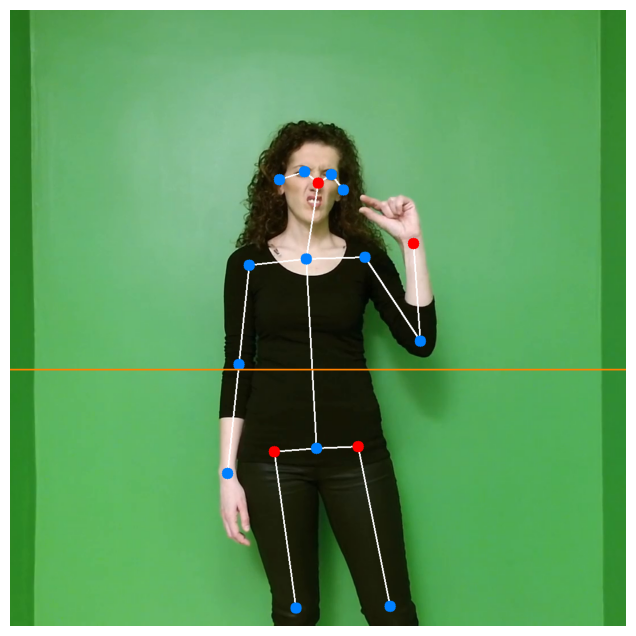

In [75]:
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# OpenPose BODY_25 Keypoint Pairs
POSE_PAIRS = [
    (1, 2), (2, 3), (3, 4),  # Right Arm
    (1, 5), (5, 6), (6, 7),  # Left Arm
    (1, 8), (8, 9), (9, 10), (10, 11),  # Right Leg
    (8, 12), (12, 13), (13, 14),  # Left Leg
    (1, 0), (0, 15), (15, 17), (0, 16), (16, 18),  # Head
    (11, 22), (22, 23), (23, 24),  # Right Foot
    (14, 19), (19, 20), (20, 21)   # Left Foot
]
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define OpenPose BODY_25 keypoints using your names

# Define POSE_PAIRS using your keypoint names
POSE_PAIRS = [
    ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),  # Right Arm
    ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),  # Left Arm
    ("neck", "middle_hip"), ("middle_hip", "right_hip"), ("right_hip", "right_knee"),  # Right Leg (With Knee)
    ("middle_hip", "left_hip"), ("left_hip", "left_knee"),  # Left Leg (With Knee)
    ("neck", "nose"), ("nose", "right_eye"), ("right_eye", "right_ear"), ("nose", "left_eye"), ("left_eye", "left_ear")  # Head
]

# Load the image
sample = "0049/User_6_002"
frame_number = 35  # Change this to the frame you need

video_path = f"/media/osero/SamsungSSD/CMPE_SSD/videos/{sample}.mp4"  # Change to your actual video file path

# Open the video file
cap = cv2.VideoCapture(video_path)

# Set the frame number you want to extract

# Set the video to the desired frame
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

# Read the frame
ret, image = cap.read()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

file_path = f"/media/osero/SamsungSSD/CMPE_SSD/skeleton_openpose/{sample}.pickle"

file = open(file_path, 'rb')
data = pickle.load(file)
keypoints = data['pose']

# Draw limbs
for pair in POSE_PAIRS:
    partA, partB = pair
    if partA in keypoints and partB in keypoints:
        xA, yA, cA = keypoints[partA][frame_number]
        xB, yB, cB = keypoints[partB][frame_number]
        cv2.line(image, (int(xA), int(yA)), (int(xB), int(yB)), (255, 255, 255), 2)  # Green lines for limbs
        
# Draw keypoints
for key, value in keypoints.items():
    x, y, c = value[frame_number]
    # x, y = coord
    if (key in {'nose', 'left_hip', 'right_hip', 'left_wrist'}):
        cv2.circle(image, (int(x), int(y)), 10, (255, 0, 0), -1)  # Red circles for joints
    else:
        cv2.circle(image, (int(x), int(y)), 10, (0, 128, 255), -1)  # Blue circles for joints


threshold = (
    (((keypoints["left_hip"][frame_number, 1] + keypoints["right_hip"][frame_number, 1]) / 2 )* 7)
    + keypoints["nose"][frame_number, 1] * 3
) / 10

cv2.line(image, (int(0), int(threshold)), (int(1920), int(threshold)), (255, 128, 0), 2)  # Green lines for limbs

middle_point = int(keypoints["nose"][frame_number, 0])
image = image[:,middle_point-540:middle_point+540]

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()


image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
im = Image.fromarray(image)
im.save('skeleton_th.png')



# All signers

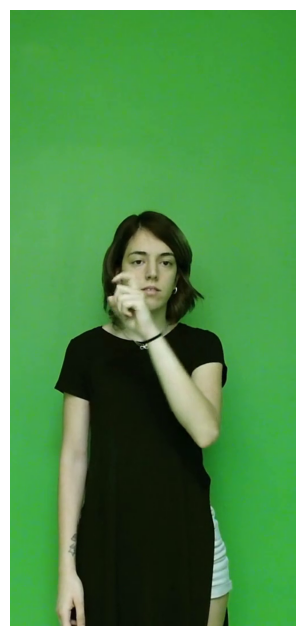

In [104]:
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# OpenPose BODY_25 Keypoint Pairs
POSE_PAIRS = [
    (1, 2), (2, 3), (3, 4),  # Right Arm
    (1, 5), (5, 6), (6, 7),  # Left Arm
    (1, 8), (8, 9), (9, 10), (10, 11),  # Right Leg
    (8, 12), (12, 13), (13, 14),  # Left Leg
    (1, 0), (0, 15), (15, 17), (0, 16), (16, 18),  # Head
    (11, 22), (22, 23), (23, 24),  # Right Foot
    (14, 19), (19, 20), (20, 21)   # Left Foot
]
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define OpenPose BODY_25 keypoints using your names

# Define POSE_PAIRS using your keypoint names
POSE_PAIRS = [
    ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),  # Right Arm
    ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),  # Left Arm
    ("neck", "middle_hip"), ("middle_hip", "right_hip"), ("right_hip", "right_knee"),  # Right Leg (With Knee)
    ("middle_hip", "left_hip"), ("left_hip", "left_knee"),  # Left Leg (With Knee)
    ("neck", "nose"), ("nose", "right_eye"), ("right_eye", "right_ear"), ("nose", "left_eye"), ("left_eye", "left_ear")  # Head
]

# Load the image
sample = "0047/User_7_001"
frame_number =45 # Change this to the frame you need

video_path = f"/media/osero/SamsungSSD/CMPE_SSD/videos/{sample}.mp4"  # Change to your actual video file path

# Open the video file
cap = cv2.VideoCapture(video_path)

# Set the frame number you want to extract

# Set the video to the desired frame
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

# Read the frame
ret, image = cap.read()
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

file_path = f"/media/osero/SamsungSSD/CMPE_SSD/skeleton_openpose/{sample}.pickle"

file = open(file_path, 'rb')
data = pickle.load(file)

keypoints = data['pose']
middle_point = int(keypoints["nose"][frame_number, 0])
image = image[:,middle_point-250:middle_point+250]

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
im = Image.fromarray(image)
im.save(f"{sample[5:]}.png")